# 와인

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
import warnings
warnings.filterwarnings(action='ignore')

### Supervised learning

In [2]:
wine = pd.read_csv('wine.csv')
del wine['Unnamed: 0']
wine

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [3]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   int64  
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


### 전처리

{'whiskers': [<matplotlib.lines.Line2D at 0x1cfb1ecaa60>,
 'caps': [<matplotlib.lines.Line2D at 0x1cfb3ee7040>,
 'boxes': [<matplotlib.lines.Line2D at 0x1cfb1eca790>],
 'medians': [<matplotlib.lines.Line2D at 0x1cfb3ee75e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1cfb3ee78b0>],
 'means': []}

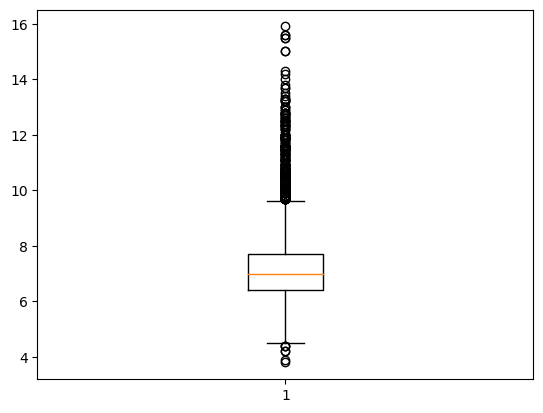

In [5]:
plt.boxplot(wine["fixed acidity"])

In [ ]:
red_wine = wine[wine["type"] == 0]["quality"]
white_wine = wine[wine["type"] == 1]["quality"]

#빈도분포대신 밀도 분포로 표시
sns.set_style("dark")
print(sns.distplot(red_wine, norm_hist=True, kde=False, color="red", label="Red wine"))
print(sns.distplot(white_wine, norm_hist=True, kde=False, color="white", label="White wine"))
plt.xlabel("Quality Score")
plt.ylabel("Density")
plt.title("Distribution of Quality by Wine Type")
plt.legend()
plt.show()

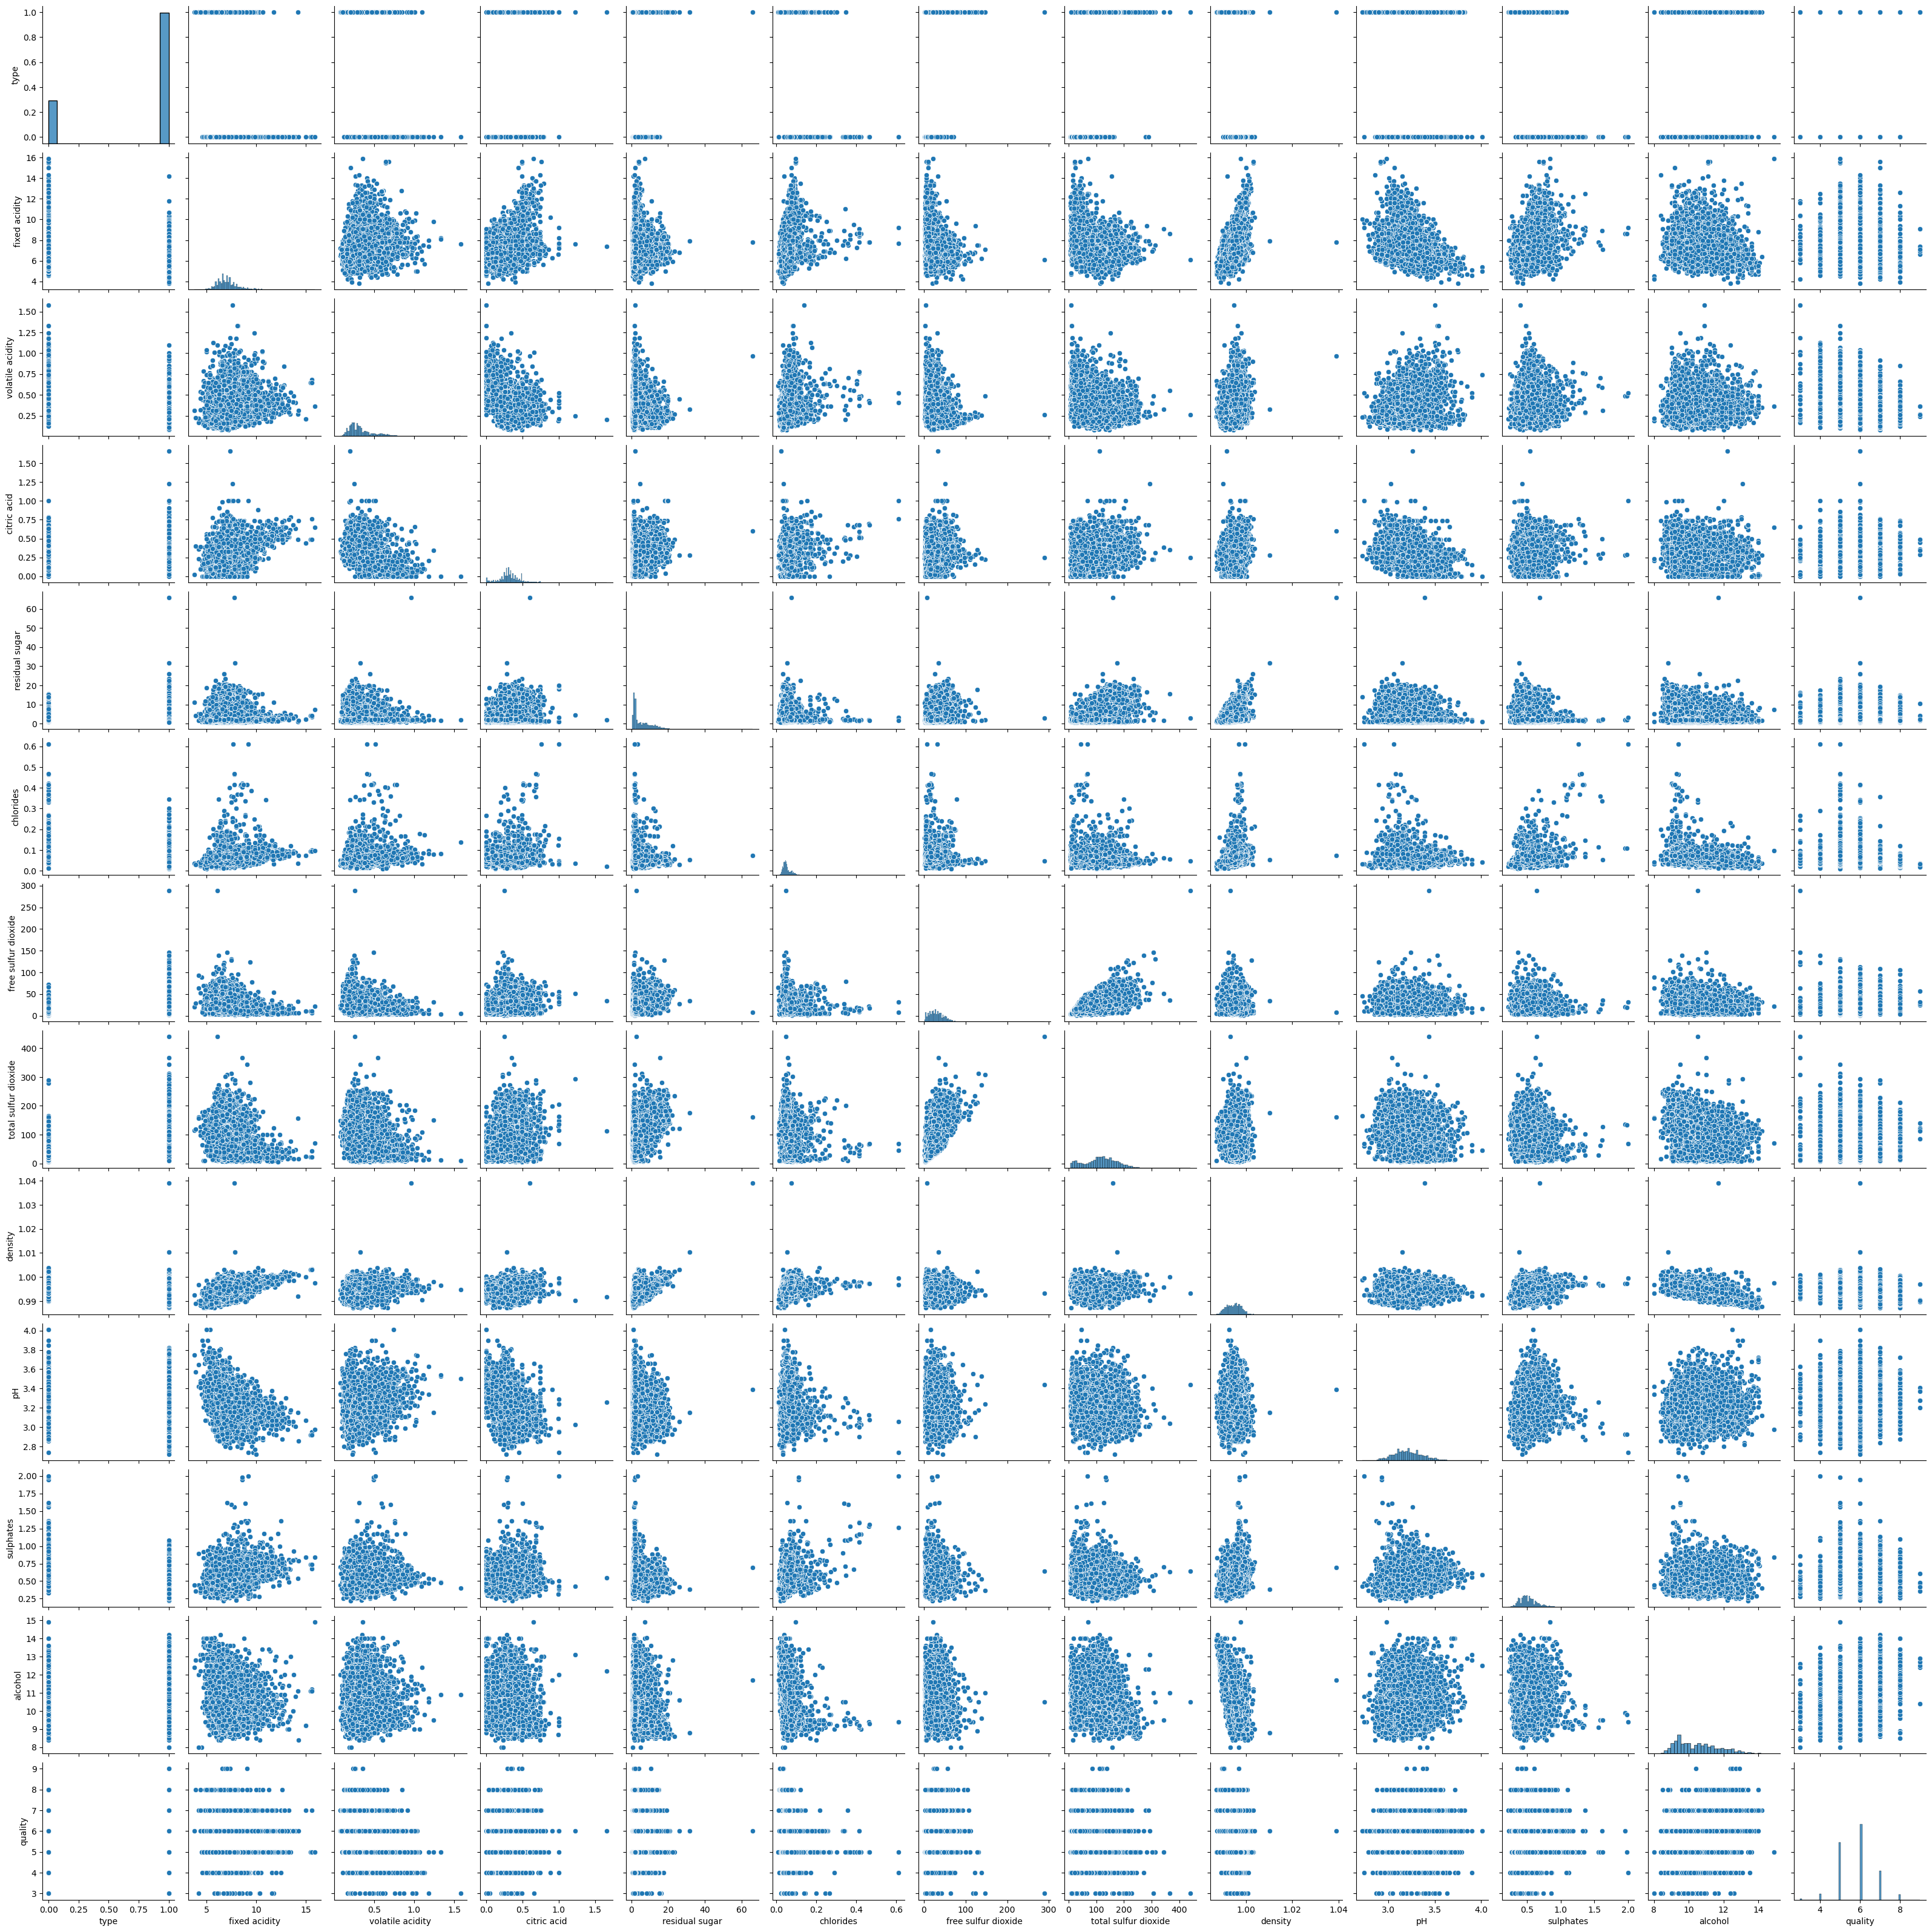

In [6]:
sns.pairplot(wine)

In [7]:
# 스케일링
from sklearn.preprocessing import StandardScaler, MinMaxScaler

col = wine.columns

# scaler = StandardScaler()
scaler = MinMaxScaler()

scaler.fit(wine)
wine = pd.DataFrame(scaler.transform(wine))
wine.columns = col
wine

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1.0,0.264463,0.126667,0.216867,0.308282,0.059801,0.152778,0.377880,0.267785,0.217054,0.129213,0.115942,0.500000
1,1.0,0.206612,0.146667,0.204819,0.015337,0.066445,0.045139,0.290323,0.132832,0.449612,0.151685,0.217391,0.500000
2,1.0,0.355372,0.133333,0.240964,0.096626,0.068106,0.100694,0.209677,0.154039,0.418605,0.123596,0.304348,0.500000
3,1.0,0.280992,0.100000,0.192771,0.121166,0.081395,0.159722,0.414747,0.163678,0.364341,0.101124,0.275362,0.500000
4,1.0,0.280992,0.100000,0.192771,0.121166,0.081395,0.159722,0.414747,0.163678,0.364341,0.101124,0.275362,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0.0,0.198347,0.346667,0.048193,0.021472,0.134551,0.107639,0.087558,0.150183,0.565891,0.202247,0.362319,0.333333
6493,0.0,0.173554,0.313333,0.060241,0.024540,0.088040,0.131944,0.103687,0.154425,0.620155,0.303371,0.463768,0.500000
6494,0.0,0.206612,0.286667,0.078313,0.026074,0.111296,0.097222,0.078341,0.166377,0.542636,0.297753,0.434783,0.500000
6495,0.0,0.173554,0.376667,0.072289,0.021472,0.109635,0.107639,0.087558,0.161172,0.658915,0.275281,0.318841,0.333333


### 분류 문제로 풀기

In [8]:
x = wine.iloc[:,1:-1]
y = wine["type"]

In [9]:
# 학습, 평가 데이터 설정
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                   test_size=0.3,
                                                   random_state=0)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost.sklearn import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [15]:
# model = LogisticRegression(C = 1, max_iter = 50)
# model = SVC(C = 1, gamma = 10)
# model = DecisionTreeClassifier(max_depth = 5, max_leaf_nodes = 10)
model = RandomForestClassifier(n_estimators = 100, max_depth = 5, max_leaf_nodes = 10)
# model = XGBClassifier(n_estimators = 100, max_depth = 5, max_leaf_nodes = 10)
# model = KNeighborsClassifier(n_neighbors = 3)

In [16]:
model.fit(x_train, y_train)

RandomForestClassifier(max_depth=5, max_leaf_nodes=10)

In [17]:
train_score = model.score(x_train, y_train)

In [18]:
test_score = model.score(x_test, y_test)

In [19]:
print(train_score, test_score, 'train - test 정확도 차이 :', train_score - test_score)

0.9898834396305256 0.9866666666666667 train - test 정확도 차이 : 0.003216772963858916


### 최적의 하이퍼 파라미터 찾기

In [20]:
c_list = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_acc = []
test_acc = []

In [21]:
for i in tqdm(c_list): 
    lr = LogisticRegression(C=i, max_iter=50)
    lr.fit(x_train, y_train)
    
    train_score = lr.score(x_train, y_train)
    test_score = lr.score(x_test, y_test)
    
    train_acc.append(train_score)
    test_acc.append(test_score)

100%|██████████| 7/7 [00:00<00:00, 37.94it/s]


In [22]:
train_acc

[0.7501649439190675,
 0.751704420497031,
 0.9696503188915768,
 0.9852650098966351,
 0.9879041126017154,
 0.990763140532219,
 0.9929623927864526]

In [23]:
test_acc

[0.7625641025641026,
 0.7630769230769231,
 0.9666666666666667,
 0.9887179487179487,
 0.9928205128205129,
 0.9948717948717949,
 0.9953846153846154]

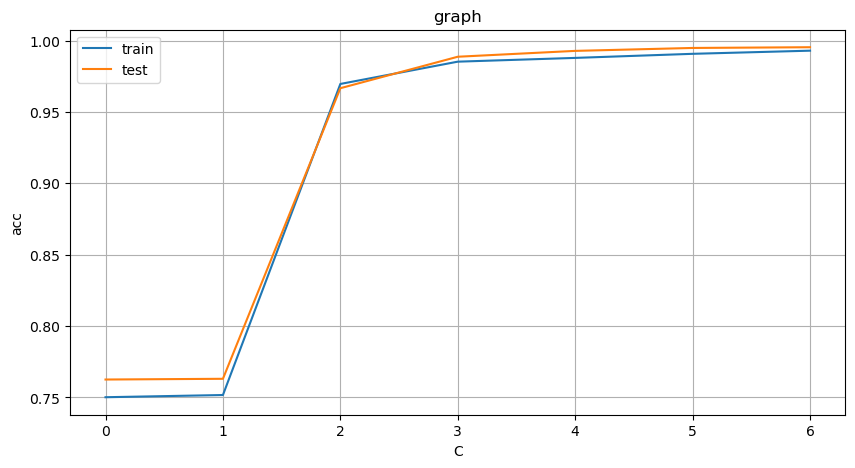

In [24]:
plt.figure(figsize=(10,5))
plt.plot(train_acc, label='train')
plt.plot(test_acc, label='test')
plt.title('graph')
plt.xlabel('C')
# plt.xticks(np.arange(7), c_list)
plt.ylabel('acc')
plt.legend()
plt.grid()
plt.show()

### 회귀 문제로 풀기

In [25]:
x = wine.iloc[:,1:-1]
y = wine["quality"]
x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.264463,0.126667,0.216867,0.308282,0.059801,0.152778,0.377880,0.267785,0.217054,0.129213,0.115942
1,0.206612,0.146667,0.204819,0.015337,0.066445,0.045139,0.290323,0.132832,0.449612,0.151685,0.217391
2,0.355372,0.133333,0.240964,0.096626,0.068106,0.100694,0.209677,0.154039,0.418605,0.123596,0.304348
3,0.280992,0.100000,0.192771,0.121166,0.081395,0.159722,0.414747,0.163678,0.364341,0.101124,0.275362
4,0.280992,0.100000,0.192771,0.121166,0.081395,0.159722,0.414747,0.163678,0.364341,0.101124,0.275362
...,...,...,...,...,...,...,...,...,...,...,...
6492,0.198347,0.346667,0.048193,0.021472,0.134551,0.107639,0.087558,0.150183,0.565891,0.202247,0.362319
6493,0.173554,0.313333,0.060241,0.024540,0.088040,0.131944,0.103687,0.154425,0.620155,0.303371,0.463768
6494,0.206612,0.286667,0.078313,0.026074,0.111296,0.097222,0.078341,0.166377,0.542636,0.297753,0.434783
6495,0.173554,0.376667,0.072289,0.021472,0.109635,0.107639,0.087558,0.161172,0.658915,0.275281,0.318841


In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                   test_size=0.3,
                                                   random_state=0)

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost.sklearn import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

In [28]:
# model = LinearRegression()
# model = Lasso(alpha = 0.1)
model = Ridge(alpha = 0.1)
# model = SVR(C = 1, gamma = 10)
# model = DecisionTreeRegressor(max_depth = 5, max_leaf_nodes = 10)
# model = RandomForestRegressor(n_estimators = 100, max_depth = 5, max_leaf_nodes = 10)
# model = XGBRegressor(n_estimators = 100, max_depth = 5, max_leaf_nodes = 10)
# model = KNeighborsRegressor(n_neighbors = 3)

In [29]:
model.fit(x_train, y_train)
train_score = model.score(x_train, y_train)
test_score = model.score(x_test, y_test)
print(train_score, test_score, 'train - test MSE 차이 :', train_score - test_score)

0.3004292692179067 0.2693035522243936 train - test MSE 차이 : 0.031125716993513075


### Unsupervised Learning

In [45]:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

wine = pd.read_csv("wine.csv", encoding = "utf-8-sig")
wine = wine.iloc[:, 2:-1]
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8
1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5
2,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1
3,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
4,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
6493,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
6494,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
6495,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [48]:
# 스케일링

col = wine.columns

# scaler = StandardScaler()
scaler = MinMaxScaler()

scaler.fit(wine)
wine = pd.DataFrame(scaler.transform(wine))
wine.columns = col
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.264463,0.126667,0.216867,0.308282,0.059801,0.152778,0.377880,0.267785,0.217054,0.129213,0.115942
1,0.206612,0.146667,0.204819,0.015337,0.066445,0.045139,0.290323,0.132832,0.449612,0.151685,0.217391
2,0.355372,0.133333,0.240964,0.096626,0.068106,0.100694,0.209677,0.154039,0.418605,0.123596,0.304348
3,0.280992,0.100000,0.192771,0.121166,0.081395,0.159722,0.414747,0.163678,0.364341,0.101124,0.275362
4,0.280992,0.100000,0.192771,0.121166,0.081395,0.159722,0.414747,0.163678,0.364341,0.101124,0.275362
...,...,...,...,...,...,...,...,...,...,...,...
6492,0.198347,0.346667,0.048193,0.021472,0.134551,0.107639,0.087558,0.150183,0.565891,0.202247,0.362319
6493,0.173554,0.313333,0.060241,0.024540,0.088040,0.131944,0.103687,0.154425,0.620155,0.303371,0.463768
6494,0.206612,0.286667,0.078313,0.026074,0.111296,0.097222,0.078341,0.166377,0.542636,0.297753,0.434783
6495,0.173554,0.376667,0.072289,0.021472,0.109635,0.107639,0.087558,0.161172,0.658915,0.275281,0.318841


In [49]:
num_clusters = 2
model = KMeans(n_clusters = num_clusters)
# model = DBSCAN(eps=0.9, min_samples=5)
# model = AgglomerativeClustering(n_clusters = num_clusters)

model.fit(wine)
kmeans_result = model.fit_predict(wine)
kmeans_result

array([1, 1, 1, ..., 0, 0, 0])

In [50]:
pca = PCA(n_components=2)
printcipalComponents = pca.fit_transform(wine)

# 주성분으로 이루어진 데이터 프레임 구성
principalDf = pd.DataFrame(data=printcipalComponents, columns = ['principal component1', 'principal component2'])
principalDf

,principal component1,principal component2
0,-0.381828,-0.022863
1,-0.094222,0.031821
2,-0.037175,0.040346
3,-0.183011,-0.099750
4,-0.183011,-0.099750
...,...,...
6492,0.172154,0.206463
6493,0.253566,0.146174
6494,0.219417,0.164152
6495,0.168212,0.263376


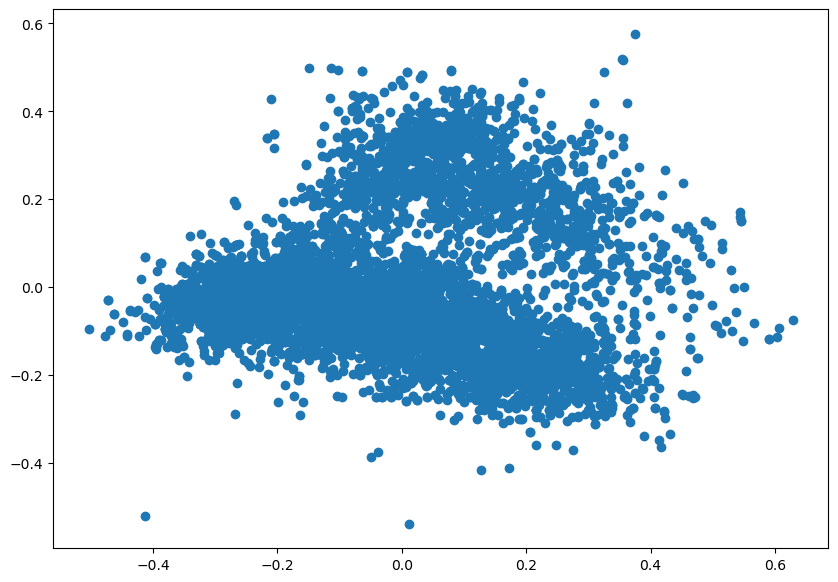

In [52]:
plt.figure(figsize=(10, 7))
plt.scatter(principalDf["principal component1"],principalDf["principal component2"])
plt.show()

100%|██████████| 6497/6497 [01:07<00:00, 96.42it/s] 


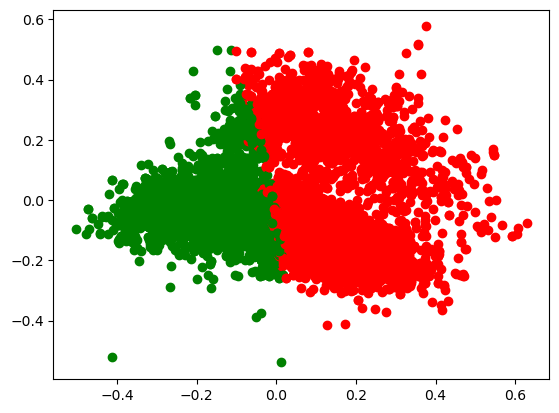

In [53]:
principalDf["kmeans"] = kmeans_result
color = ["red", "green", "blue"]
for i in tqdm(principalDf.index):
    plt.scatter(principalDf["principal component1"].loc[i],
                principalDf["principal component2"].loc[i],
                color = color[principalDf["kmeans"].loc[i]])